In [ ]:
!pip install -U pip -q
!pip install -U torchao peft transformers datasets accelerate pyarrow underthesea matplotlib -q

In [1]:
import os, json, time, zipfile, math, gc
import numpy as np
from pathlib import Path
from datetime import datetime
from itertools import cycle

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from datasets import load_dataset, Dataset, DatasetDict, load_from_disk, Features, Value, ClassLabel
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup, get_linear_schedule_with_warmup
import shutil
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB')

PyTorch 2.10.0+cu128 | Device: cuda
GPU: Tesla T4 | VRAM: 15.6GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted')

In [2]:
# CONFIG - Chỉnh tại đây
CONFIG = {
    # Đường dẫn file
    'zip_path'    : '/content/drive/MyDrive/Học sâu 252AI31001/Data_Preprocessed.zip',
    'extract_dir' : '/kaggle/working/parquet_files',
    'cache_dir'   : '/kaggle/working/hf_cache',
    'dataset_path': '/kaggle/working/hf_dataset',
    # Thư mục lưu checkpoint + log + best model
    'output_dir'  : '/kaggle/working/checkpoints',

    # Cấu hình Model
    'model_name'  : 'vinai/phobert-base',
    'max_length'  : 256,
    'lora_r'      : 16,
    'lora_alpha'  : 32,
    'lora_dropout': 0.1,

    # Tham số Train
    'batch_size'          : 32,
    'grad_accum_steps'    : 2,
    'learning_rate'       : 2e-5,
    'epochs'              : 5,
    'warmup_ratio'        : 0.1,
    'grad_clip'           : 1.0,

    # Cấu hình Loss
    'focal_gamma' : 2.0,
    'focal_alpha' : 0.5,

    # Điểm dừng sớm
    'early_stop_patience': 3, # dừng nếu F1 không tăng sau 3 lần validate

    # Tỷ lệ chia
    'val_size'  : 0.1,
    'test_size' : 0.1,
    'seed'      : 42,
    'num_proc'  : 4,

    'eval_every_steps': 1000,   # Buoc danh gia model
    'save_every_steps': 2000,   # Buoc luu checkpoint
}

# Tao thu muc luu tru
for p in ['output_dir', 'extract_dir', 'cache_dir']:
    Path(CONFIG[p]).mkdir(parents=True, exist_ok=True)
os.makedirs(CONFIG['output_dir'], exist_ok=True)

# Duong dan file out
CKPT_PATH       = os.path.join(CONFIG['output_dir'], 'checkpoint.pt')
BEST_MODEL_PATH = os.path.join(CONFIG['output_dir'], 'best_model.pt')
LOG_PATH        = os.path.join(CONFIG['output_dir'], 'training_log.json')
CONFIG_PATH     = os.path.join(CONFIG['output_dir'], 'model_config.json')
META_PATH       = os.path.join(CONFIG['output_dir'], 'feature_engineering.json')

In [ ]:
# Duong dan file goc
PARQUET_DIR = "/kaggle/input/datasets/bangta205/scam-detection-datasets-preprocessed" 

print("Lien ket file goc...")
# Doc file tu dia
raw_dataset = load_dataset(
    "parquet", 
    data_files=os.path.join(PARQUET_DIR, "*.parquet"), 
    split="train",
    keep_in_memory=False
)

# Ep kieu nhan
raw_dataset = raw_dataset.cast_column("label", ClassLabel(num_classes=2, names=["clean", "scam"]))

# --- KIEM TRA LECH NHAN ---
print("\n   KIEM TRA LECH NHAN")
total_records = len(raw_dataset)

print("Dang nap rieng nhan...")
# Doc rieng cot nhan
label_ds = load_dataset(
    "parquet", 
    data_files=os.path.join(PARQUET_DIR, "*.parquet"), 
    split="train", 
    columns=["label"]
)
labels_array = np.array(label_ds["label"], dtype=np.int8)

# Dem so luong nhan
counts = np.bincount(labels_array)
clean_count = counts[0] if len(counts) > 0 else 0
scam_count = counts[1] if len(counts) > 1 else 0

print(f"Tong so ban ghi: {total_records:,}")
print(f"  - CLEAN (0): {clean_count:,} dong ({clean_count/total_records*100:.2f}%)")
print(f"  - SCAM (1) : {scam_count:,} dong ({scam_count/total_records*100:.2f}%)")

# Xoa mang tam
del label_ds
gc.collect()

# --- CAN BANG DU LIEU ---
print("\n   CAN BANG NHAN")
minority_size = min(clean_count, scam_count)
print(f"-> Boc moi ben: {minority_size:,} dong.")

# Tim vi tri nhan
clean_indices = np.where(labels_array == 0)[0]
scam_indices = np.where(labels_array == 1)[0]

print("Dang lay mau...")
# Lay mau ngau nhien
np.random.seed(CONFIG['seed'])
if clean_count > scam_count:
    chosen_clean = np.random.choice(clean_indices, size=minority_size, replace=False)
    chosen_scam = scam_indices
else:
    chosen_clean = clean_indices
    chosen_scam = np.random.choice(scam_indices, size=minority_size, replace=False)

# Tron deu chi muc
chosen_all = np.concatenate([chosen_clean, chosen_scam])
np.random.shuffle(chosen_all)

print("Dang trich xuat...")
# Trich xuat du lieu
balanced_dataset = raw_dataset.select(chosen_all, keep_in_memory=True)
print(f"Tong so sau can bang: {len(balanced_dataset):,} dong.")

# Xoa mang tam
del labels_array, clean_indices, scam_indices, chosen_clean, chosen_scam, chosen_all
gc.collect()

# --- MAP ---
print("\n   CHUAN HOA DATA")
# Tao cau truc moi
new_features = balanced_dataset.features.copy()
new_features["n_subs_norm"] = Value("float32")

# Ham chuan hoa metadata
def preprocess_function(examples):
    subs = np.array(examples['n_subscribers'])
    max_s = 5000000
    examples['n_subs_norm'] = np.log1p(subs) / np.log1p(max_s)
    examples['label'] = [int(l) for l in examples['label']]
    return examples

# Chuan hoa voi batch lon
processed_dataset = balanced_dataset.map(
    preprocess_function, 
    batched=True, 
    batch_size=250000, 
    writer_batch_size=250000, 
    features=new_features, 
    num_proc=CONFIG['num_proc'],
    keep_in_memory=True,
    load_from_cache_file=False,
    desc="Chuan hoa"
)

# --- CHIA TAP DATA ---
print("\n   CHIA TAP DATA")
# Tinh ty le chia
holdout = CONFIG["val_size"] + CONFIG["test_size"]

# Tach tap Train
splits = processed_dataset.train_test_split(
    test_size=holdout,
    seed=CONFIG["seed"],
    stratify_by_column="label",
    keep_in_memory=True
)
train_ds = splits['train']

# Tach Val va Test
test_val_splits = splits['test'].train_test_split(
    test_size=0.5,
    seed=CONFIG["seed"],
    stratify_by_column="label",
    keep_in_memory=True
)
val_ds = test_val_splits['train']
test_ds = test_val_splits['test']

print(f"  - TRAIN : {len(train_ds):,}")
print(f"  - VAL   : {len(val_ds):,}")
print(f"  - TEST  : {len(test_ds):,}")

# Don rac bo nho
gc.collect()

Lien ket file goc...


Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/32 [00:00<?, ?it/s]

Casting the dataset:   0%|          | 0/34245696 [00:00<?, ? examples/s]

In [5]:
print("Hop nhat cac tap du lieu da tokenize...")
# Gop 3 tap du lieu vao mot cau truc DatasetDict
final_tokenized_dataset = DatasetDict({
    'train': tokenized_train,
    'validation': tokenized_val,
    'test': tokenized_test
})

# Thiet lap duong dan luu file
SAVE_DIR = "/kaggle/working/scam_dataset_tokenized"
ZIP_OUTPUT = "/kaggle/working/scam_dataset_tokenized"

print("Luu cung xuong o dia virtual...")
final_tokenized_dataset.save_to_disk(SAVE_DIR)
print(f"Da luu xong tai: {SAVE_DIR}")

print("\nNen thanh file .zip de tai ve...")
# Nen zip folder vua luu de tải về máy dễ dàng
shutil.make_archive(ZIP_OUTPUT, 'zip', SAVE_DIR)
print(f"File san sang tai ve: {ZIP_OUTPUT}.zip")

Hop nhat cac tap du lieu da tokenize...
Luu cung xuong o dia virtual...


Saving the dataset (0/1 shards):   0%|          | 0/139398 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/17425 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/17425 [00:00<?, ? examples/s]

Da luu xong tai: /kaggle/working/scam_dataset_tokenized

Nen thanh file .zip de tai ve...
File san sang tai ve: /kaggle/working/scam_dataset_tokenized.zip


In [3]:
# Thu muc nguon tu input
INPUT_DIR = "/kaggle/input/datasets/bangta205/scam-dataset-tokenized"
# Thu muc dich den working
WORKING_DIR = "/kaggle/working/scam_dataset_tokenized"

# Tien hanh sao chep
if os.path.exists(INPUT_DIR):
    if os.path.exists(WORKING_DIR):
        # Xoa neu trung folder
        shutil.rmtree(WORKING_DIR)
    # Copy nguyen folder sang
    shutil.copytree(INPUT_DIR, WORKING_DIR)
    print("Copy data thanh cong")
else:
    print("Khong tim thay nguon")

Copy data thanh cong


In [4]:
# # TOKENIZE TOAN BO DATA 
# print("Tokenize...")
# tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

# # Ham tokenize hang loat
# def tokenize_batch_function(examples):
#     return tokenizer(
#         examples['cleaned_text'],
#         max_length=CONFIG['max_length'],
#         padding='max_length',
#         truncation=True
#     )

# # Chuan hoa tokenize luong
# tokenized_train = train_ds.map(tokenize_batch_function, batched=True, batch_size=50000, num_proc=CONFIG['num_proc'], keep_in_memory=True, load_from_cache_file=False, desc="Tokenize Train")
# tokenized_val = val_ds.map(tokenize_batch_function, batched=True, batch_size=50000, num_proc=CONFIG['num_proc'], keep_in_memory=True, load_from_cache_file=False, desc="Tokenize Val")
# tokenized_test = test_ds.map(tokenize_batch_function, batched=True, batch_size=50000, num_proc=CONFIG['num_proc'], keep_in_memory=True, load_from_cache_file=False, desc="Tokenize Test")

tokenized_train = load_from_disk("/kaggle/working/scam_dataset_tokenized/train")
tokenized_val   = load_from_disk("/kaggle/working/scam_dataset_tokenized/validation")
tokenized_test  = load_from_disk("/kaggle/working/scam_dataset_tokenized/test")

# PYTORCH DATASET
class ScamDataset(Dataset):
    def __init__(self, hf_tokenized_dataset):
        self.dataset = hf_tokenized_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Xu ly neu idx la list
        if isinstance(idx, list):
            item = self.dataset[idx]
            # Doc va ep kieu mang
            return {
                'input_ids'     : torch.tensor(item['input_ids'], dtype=torch.long),
                'attention_mask': torch.tensor(item['attention_mask'], dtype=torch.long),
                'metadata'      : torch.tensor(
                    [[float(h), float(v), float(n)] for h, v, n in zip(item['has_url'], item['verified'], item['n_subs_norm'])],
                    dtype=torch.float
                ),
                'label'         : torch.tensor([int(l) for l in item['label']], dtype=torch.long)
            }
        
        # Xu ly neu idx la so don
        item = self.dataset[int(idx)]
        return {
            'input_ids'     : torch.tensor(item['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(item['attention_mask'], dtype=torch.long),
            'metadata'      : torch.tensor(
                [float(item['has_url']), float(item['verified']), float(item['n_subs_norm'])],
                dtype=torch.float
            ),
            'label'         : torch.tensor(int(item['label']), dtype=torch.long)
        }

# Khoi tao dataset
train_dataset_pytorch = ScamDataset(tokenized_train)
val_dataset_pytorch   = ScamDataset(tokenized_val)
test_dataset_pytorch  = ScamDataset(tokenized_test)


# DATALOADER
print("\nKhoi tao DataLoader...")
train_loader = DataLoader(
    train_dataset_pytorch, 
    batch_size=CONFIG['batch_size'],
    shuffle=True, 
    num_workers=2, 
    pin_memory=True
)

val_loader   = DataLoader(
    val_dataset_pytorch,   
    batch_size=CONFIG['batch_size']*2,
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

test_loader  = DataLoader(
    test_dataset_pytorch,  
    batch_size=CONFIG['batch_size']*2,
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

# TINH STEP THEO DATA 
# Lay do dai loader lam step
steps_per_epoch = len(train_loader) 
total_steps = CONFIG['epochs'] * steps_per_epoch
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

# In thong so kiem tra
print(f"\nConfig OK | Device: {device}")
print(f"Actual Train: {CONFIG['epochs']} epochs x {steps_per_epoch:,} steps = {total_steps:,} total steps")
print(f"Warmup steps: {warmup_steps:,} | Effective batch size: {CONFIG['batch_size'] * CONFIG['grad_accum_steps']}")


Khoi tao DataLoader...

Config OK | Device: cuda
Actual Train: 5 epochs x 4,357 steps = 21,785 total steps
Warmup steps: 2,178 | Effective batch size: 64


In [28]:
from datasets import load_from_disk

# Load dữ liệu từ đĩa ảo Kaggle
tokenized_dataset = load_from_disk("/kaggle/working/scam_dataset_tokenized")

# In ra danh sách tên tất cả các cột
print("Tên các cột trong bộ dữ liệu:", tokenized_dataset.column_names)

# Đếm tổng số lượng cột dữ liệu
print("Tổng số lượng cột:", len(tokenized_dataset.column_names))

# Xem cấu trúc chi tiết và kiểu dữ liệu của từng cột
print("\nCấu trúc chi tiết:")
print(tokenized_dataset)

Tên các cột trong bộ dữ liệu: {'train': ['cleaned_text', 'has_url', 'label', 'n_subscribers', 'verified', 'n_subs_norm', 'input_ids', 'attention_mask'], 'validation': ['cleaned_text', 'has_url', 'label', 'n_subscribers', 'verified', 'n_subs_norm', 'input_ids', 'attention_mask'], 'test': ['cleaned_text', 'has_url', 'label', 'n_subscribers', 'verified', 'n_subs_norm', 'input_ids', 'attention_mask']}
Tổng số lượng cột: 3

Cấu trúc chi tiết:
DatasetDict({
    train: Dataset({
        features: ['cleaned_text', 'has_url', 'label', 'n_subscribers', 'verified', 'n_subs_norm', 'input_ids', 'attention_mask'],
        num_rows: 139398
    })
    validation: Dataset({
        features: ['cleaned_text', 'has_url', 'label', 'n_subscribers', 'verified', 'n_subs_norm', 'input_ids', 'attention_mask'],
        num_rows: 17425
    })
    test: Dataset({
        features: ['cleaned_text', 'has_url', 'label', 'n_subscribers', 'verified', 'n_subs_norm', 'input_ids', 'attention_mask'],
        num_rows: 174

In [8]:
import os
from transformers import AutoTokenizer

# --- Set path ---
TOKENIZER_OUT = '/kaggle/working/demo_deployment/tokenizer'
os.makedirs(TOKENIZER_OUT, exist_ok=True)

# --- Load tokenizer ---
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

# --- Save tokenizer ---
tokenizer.save_pretrained(TOKENIZER_OUT)
print("Saved tokenizer config")

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Saved tokenizer config


In [9]:
# --- Set folder path ---
source_dir = '/kaggle/working/demo_deployment/tokenizer'
output_zip = '/kaggle/working/demo_deployment/tokenizer'

# --- Compress folder ---
shutil.make_archive(output_zip, 'zip', source_dir)
print("Done")

Done


In [5]:
class LocalLoRALinear(nn.Module):
    # Khởi tạo lớp LoRA
    def __init__(self, original_layer: nn.Linear, r: int = 16, alpha: int = 32, dropout: float = 0.1):
        super().__init__()
        self.original_layer = original_layer
        
        # Đóng băng mạng gốc
        self.original_layer.weight.requires_grad = False
        if self.original_layer.bias is not None:
            self.original_layer.bias.requires_grad = False
            
        self.r = r
        self.scaling = alpha / r
        
        in_features = original_layer.in_features
        out_features = original_layer.out_features
        
        # Ma trận hạng thấp
        self.lora_A = nn.Parameter(torch.zeros((r, in_features)))
        self.lora_B = nn.Parameter(torch.zeros((out_features, r)))
        
        self.lora_dropout = nn.Dropout(p=dropout)
        
        # Khởi tạo trọng số
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    # Lan truyền thuận
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Tính toán luồng gốc
        result = self.original_layer(x)
        
        # Ép kiểu ma trận tăng tốc GPU
        lora_A_scaled = self.lora_A * self.scaling
        
        # Gom toán tử nhân ma trận
        x_dropped = self.lora_dropout(x)
        lora_out = (x_dropped @ lora_A_scaled.t()) @ self.lora_B.t()
        
        # Cộng hợp kết quả
        return result + lora_out

In [6]:
# KIEN TRUC MODEL 
class ScamClassifier(nn.Module):
    # Khởi tạo mô hình
    def __init__(self, model_name, lora_r=16, lora_alpha=32, lora_dropout=0.1, num_meta=3, num_classes=2):
        super().__init__()
        # Tải backbone phobert
        self.encoder = AutoModel.from_pretrained(model_name)
        
        # Tiêm lớp lora custom
        for name, module in self.encoder.named_modules():
            if any(target in name for target in ['query', 'key', 'value']) and isinstance(module, nn.Linear):
                parent_name = ".".join(name.split(".")[:-1])
                child_name = name.split(".")[-1]
                parent_module = dict(self.encoder.named_modules())[parent_name]
                
                # Thay thế cấu trúc
                setattr(parent_module, child_name, LocalLoRALinear(module, r=lora_r, alpha=lora_alpha, dropout=lora_dropout))
        
        # Tạo đầu phân loại
        hidden_size = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden_size + num_meta, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    # Khởi chạy mô hình
    def forward(self, input_ids, attention_mask, metadata):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # Lấy token CLS
        cls_embedding = out.last_hidden_state[:, 0, :]
        
        # Ghép nối dữ liệu
        x = torch.cat([cls_embedding, metadata], dim=1)
        return self.head(x)

# Khởi tạo mạng sâu
model = ScamClassifier(CONFIG['model_name'], lora_r=CONFIG['lora_r'], lora_alpha=CONFIG['lora_alpha'])
model = model.to(device)

# Đếm tổng tham số
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} || All params: {all_params:,} || Trainable%: {100 * trainable_params / all_params:.4f}%")

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Trainable params: 114,819,842 || All params: 136,081,154 || Trainable%: 84.3760%


In [7]:
# Ham Focal Loss + Optimizer + Scheduler
class FocalLoss(nn.Module):
    """
    Focal Loss - Giam dong gop samples de
    gamma : focusing parameter (2 la chuan)
    alpha : weight cho class Scam=True (0.5 do data can bang)
    """
    def __init__(self, gamma=2.0, alpha=0.5):
        super().__init__()
        self.gamma = gamma
        # Trọng số nhãn mặc định
        self.register_buffer('weight', torch.tensor([1.0 - alpha, alpha], dtype=torch.float))

    def forward(self, logits, targets):
        # Ép weight theo thiết bị logits
        weight_device = self.weight.to(logits.device)
        
        # Truyền weight chuẩn thiết bị vào hàm ce
        ce   = nn.functional.cross_entropy(logits, targets, weight=weight_device, reduction='none')
        pt   = torch.exp(-ce)
        fl   = (1 - pt) ** self.gamma * ce
        return fl.mean()


# Khoi tao loss function
criterion = FocalLoss(gamma=CONFIG['focal_gamma'], alpha=CONFIG['focal_alpha'])

# --- OPTIMIZER TOI UU ---
# Chi loc tham so can train
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['learning_rate'], 
    weight_decay=0.01
)

# --- SCHEDULER DIEU TOC ---
# Su dung luon bien da tinh toan tu dataloader
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps  = warmup_steps,
    num_training_steps= total_steps
)

# --- MIXED PRECISION ACELERATOR ---
scaler = torch.amp.GradScaler('cuda')   

print(f'Optimizer ready | Total steps: {total_steps:,} | Warmup: {warmup_steps:,}')

Optimizer ready | Total steps: 21,785 | Warmup: 2,178


In [8]:
# HAM LUU CHECKPOINT
def save_checkpoint(epoch, global_step, best_f1, history):
    # Đồng bộ tham số model
    ckpt_data = {
        'epoch': epoch,
        'global_step': global_step,
        'model_state_dict': model.state_dict(), 
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'scaler_state': scaler.state_dict(),
        'best_f1': best_f1,
    }
    
    # Ghi file trung gian
    temp_ckpt_path = CKPT_PATH + ".tmp"
    torch.save(ckpt_data, temp_ckpt_path)
    os.replace(temp_ckpt_path, CKPT_PATH)
    
    # Xuất lịch sử train
    with open(LOG_PATH, 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=2, ensure_ascii=False)
        
    # Xuất cấu hình config
    with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
        json.dump(CONFIG, f, indent=2, ensure_ascii=False)
        
    # Xuất thông tin metadata
    meta_features = {
        "label_map": {
            "clean": 0,
            "scam": 1
        },
        "feature_engineering": {
            "n_subscribers_max_scale": 5000000,
            "text_max_length": CONFIG['max_length'],
            "metadata_columns": ["has_url", "verified", "n_subs_norm"]
        }
    }
    with open(META_PATH, 'w', encoding='utf-8') as f:
        json.dump(meta_features, f, indent=2, ensure_ascii=False)
        
    print(f'   Checkpoint saved (epoch={epoch+1}, step={global_step:,}, best_f1={best_f1:.4f})')


# Khôi phục từ checkpoint
def load_checkpoint():
    """Returns (start_epoch, start_step, best_f1, history)"""
    # Kiểm tra file tồn tại
    if not os.path.exists(CKPT_PATH):
        print('   Khong tim thay checkpoint -> bat dau moi.')
        return 0, 0, 0.0, []

    # Tải file từ thiết bị
    ckpt = torch.load(CKPT_PATH, map_location=device)
    
    # Nạp toàn bộ trọng số
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    scaler.load_state_dict(ckpt['scaler_state'])

    # Đọc log lịch sử
    history = json.load(open(LOG_PATH)) if os.path.exists(LOG_PATH) else []
    epoch  = ckpt['epoch']
    step   = ckpt['global_step']
    best_f1= ckpt['best_f1']
    print(f'Resume tu epoch={epoch+1}, step={step:,}, best_f1={best_f1:.4f}')
    return epoch, step, best_f1, history

# Lưu trọng số tốt nhất
def save_best_model(best_f1):
    # Lưu file best model
    torch.save(model.state_dict(), BEST_MODEL_PATH)
    print(f'      -> Lưu trọng số best_model.pt (F1={best_f1:.4f})')
print('Checkpoint helpers ready')

Checkpoint helpers ready


In [9]:
# Evaluate 
# HAM DANH GIA MODEL 
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    preds_all, labels_all = [], []

    # Vong lap duyet batch
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        meta = batch['metadata'].to(device)
        lbl  = batch['label'].to(device)

        # Tinh toan precision mien
        with torch.amp.autocast('cuda'):
            logits = model(ids, mask, meta)
            loss   = criterion(logits, lbl)

        total_loss += loss.item()
        
        # Giu nguyen tensor tren GPU
        preds_all.append(torch.argmax(logits, dim=1))
        labels_all.append(lbl)

    # Gop mảng một lần tren GPU
    preds_all = torch.cat(preds_all).cpu().numpy()
    labels_all = torch.cat(labels_all).cpu().numpy()

    # Tinh toán cac chi so
    metrics = {
        'loss'     : total_loss / len(loader),
        'f1'       : f1_score(labels_all, preds_all, average='binary', zero_division=0),
        'precision': precision_score(labels_all, preds_all, average='binary', zero_division=0),
        'recall'   : recall_score(labels_all, preds_all, average='binary', zero_division=0),
        'accuracy' : accuracy_score(labels_all, preds_all), # Dung sk-learn nhanh hon
    }

    # Tra lai trang thai train
    model.train()
    
    # Don sach bo nho GPU
    del preds_all, labels_all
    torch.cuda.empty_cache()
    
    return metrics

print('Evaluate helper ready')

Evaluate helper ready


In [10]:
# TRAINING LOOP
start_epoch, global_step, best_f1, history = load_checkpoint()
patience_counter = 0
steps_per_epoch  = len(train_loader)

# In header thong tin
print(f"\n{'='*65}")
print(f' Training | Epochs {start_epoch+1} -> {CONFIG["epochs"]} | Steps/epoch ≈ {steps_per_epoch:,}')
print(f" Save every {CONFIG['save_every_steps']:,} steps | Eval every {CONFIG['eval_every_steps']:,} steps")
print(f"{'='*65}\n")

# Thiet lap trang thai train
model.train()
optimizer.zero_grad() 
epoch_loss = 0.0

# Vong lap xuyen epoch
for epoch in range(start_epoch, CONFIG['epochs']):
    epoch_start = time.time()

    for step_in_epoch, batch in enumerate(train_loader):

        # Logic bo qua neu resume
        steps_done_in_epoch = global_step - epoch * steps_per_epoch
        if step_in_epoch < steps_done_in_epoch:
            continue

        # Day du lieu len thiet bi
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        meta = batch['metadata'].to(device)
        lbl  = batch['label'].to(device)

        # Tinh toan loss autocast
        with torch.amp.autocast('cuda'):
            logits = model(ids, mask, meta)
            loss   = criterion(logits, lbl)
            # Chia loss theo buoc tich luy
            loss = loss / CONFIG['grad_accum_steps']

        # Lan truyen gradient
        scaler.scale(loss).backward()
        epoch_loss += loss.item() * CONFIG['grad_accum_steps']

        # CAP NHAT TRONG SO THEO ACCUMULATION
        if (step_in_epoch + 1) % CONFIG['grad_accum_steps'] == 0 or (step_in_epoch + 1) == steps_per_epoch:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            global_step += 1

            # Log thong so dinh ky
            if global_step % 500 == 0:
                avg_loss = epoch_loss / (step_in_epoch + 1)
                lr_now   = scheduler.get_last_lr()[0]
                # CHỈNH SỬA TẠI ĐÂY: Tính thời gian trôi qua theo phút thay vì giây
                elapsed_min = (time.time() - epoch_start) / 60.0
                print(f'   Epoch {epoch+1} | Step {global_step:,} | loss={avg_loss:.4f} | lr={lr_now:.2e} | {elapsed_min:.1f}m')

            # Validate hoan chinh
            if global_step % CONFIG['eval_every_steps'] == 0:
                m   = evaluate(val_loader)
                ts  = datetime.now().isoformat()
                row = {
                    'epoch'      : epoch + 1,
                    'global_step': global_step,
                    'train_loss' : epoch_loss / (step_in_epoch + 1),
                    **{f'val_{k}': v for k,v in m.items()},
                    'timestamp'  : ts
                }
                history.append(row)
                print(f'\n   EVAL step={global_step:,}')
                print(f'      Val Loss={m["loss"]:.4f} | F1={m["f1"]:.4f} | Prec={m["precision"]:.4f} | Recall={m["recall"]:.4f}')

                # Kiem tra dinh F1
                if m['f1'] > best_f1:
                    best_f1 = m['f1']
                    save_best_model(best_f1)
                    patience_counter = 0
                else:
                    patience_counter += 1
                    print(f'      No improvement ({patience_counter}/{CONFIG["early_stop_patience"]})')
                    if patience_counter >= CONFIG['early_stop_patience']:
                        print('\nEarly stopping triggered!')
                        save_checkpoint(epoch, global_step, best_f1, history)
                        raise SystemExit

            # Luu dinh ky step
            if global_step % CONFIG['save_every_steps'] == 0:
                save_checkpoint(epoch, global_step, best_f1, history)

    # KET THUC MOT EPOCH
    epoch_elapsed_min = (time.time() - epoch_start) / 60.0
    print(f'\n✔ Epoch {epoch+1} done | avg_loss={epoch_loss/steps_per_epoch:.4f} | {epoch_elapsed_min:.1f}m')
    save_checkpoint(epoch, global_step, best_f1, history)
    epoch_loss = 0.0 # Reset cuoi epoch

print(f"\n{'='*65}")
print(f' Training complete! Best Val F1 = {best_f1:.4f}')
print(f"{'='*65}")

   Khong tim thay checkpoint -> bat dau moi.

 Training | Epochs 1 -> 5 | Steps/epoch ≈ 4,357
 Save every 2,000 steps | Eval every 1,000 steps

   Epoch 1 | Step 500 | loss=0.0219 | lr=4.59e-06 | 3.5m
   Epoch 1 | Step 1,000 | loss=0.0181 | lr=9.18e-06 | 7.2m

   EVAL step=1,000
      Val Loss=0.0120 | F1=0.8926 | Prec=0.9150 | Recall=0.8713
      -> Lưu trọng số best_model.pt (F1=0.8926)
   Epoch 1 | Step 1,500 | loss=0.0160 | lr=1.38e-05 | 11.4m
   Epoch 1 | Step 2,000 | loss=0.0149 | lr=1.84e-05 | 15.1m

   EVAL step=2,000
      Val Loss=0.0113 | F1=0.8985 | Prec=0.8980 | Recall=0.8991
      -> Lưu trọng số best_model.pt (F1=0.8985)
   Checkpoint saved (epoch=1, step=2,000, best_f1=0.8985)

✔ Epoch 1 done | avg_loss=0.0145 | 17.0m
   Checkpoint saved (epoch=1, step=2,179, best_f1=0.8985)
   Epoch 2 | Step 2,500 | loss=0.0102 | lr=1.97e-05 | 2.4m
   Epoch 2 | Step 3,000 | loss=0.0099 | lr=1.92e-05 | 6.0m

   EVAL step=3,000
      Val Loss=0.0094 | F1=0.9244 | Prec=0.9414 | Recall=0.9

In [40]:
import glob

# Force disk sync
os.sync()

# Set target directory
target_dir = '/kaggle/working/checkpoints'
print(f"Checking directory: {target_dir}")

# List all files
files = glob.glob(os.path.join(target_dir, '*'))
print(f"Found {len(files)} files inside:")

for f in files:
    # Print file details
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"- {os.path.basename(f)} ({size_mb:.2f} MB)")

Checking directory: /kaggle/working/checkpoints
Found 11 files inside:
- feature_engineering.json (0.00 MB)
- model_config.json (0.00 MB)
- system_performance_report.json (0.00 MB)
- training_log.json (0.00 MB)
- training_loss_accuracy.png (0.20 MB)
- confusion_matrix.png (0.08 MB)
- training_curve.png (0.13 MB)
- roc_auc_curve.png (0.11 MB)
- best_model.pt (519.22 MB)
- precision_recall_curve.png (0.08 MB)
- checkpoint.pt (1390.89 MB)


In [37]:
import torch
from peft import get_peft_model, set_peft_model_state_dict

# --- Initialize model ---
model = ScamClassifier(CONFIG['model_name'])

# --- Apply LoRA ---
model.encoder = get_peft_model(model.encoder, lora_cfg)

# --- Load checkpoint ---
ckpt = torch.load(BEST_MODEL_PATH, map_location=device)

# --- Load weights ---
set_peft_model_state_dict(model.encoder, ckpt['lora_state'])
model.head.load_state_dict(ckpt['head_state'])

# --- Merge LoRA ---
model.encoder = model.encoder.merge_and_unload()

# --- Pack model ---
full_model_data = {
    'model_state_dict': model.state_dict(),
    'best_f1': ckpt['best_f1']
}

In [39]:
# --- Init model ---
native_model = ScamClassifier(CONFIG['model_name'])

# --- Load weights ---
model_data = torch.load('/kaggle/working/checkpoints/best_model.pt', map_location=device)
native_model.load_state_dict(model_data)
native_model = native_model.to(device)
native_model.eval()

# --- Evaluate test ---
labels_all = []
preds_all = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        metadata = batch['metadata'].to(device)
        labels = batch['label'].to(device)
        
        with torch.amp.autocast('cuda'):
            logits = native_model(input_ids, attention_mask, metadata)
            
        preds = torch.argmax(logits, dim=1)
        labels_all.extend(labels.cpu().numpy())
        preds_all.extend(preds.cpu().numpy())

# --- Print report ---
print(classification_report(labels_all, preds_all, target_names=['Bình thường (0)', 'Lừa đảo/Scam (1)'], digits=4))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                  precision    recall  f1-score   support

 Bình thường (0)     0.9207    0.9650    0.9423      8712
Lừa đảo/Scam (1)     0.9632    0.9169    0.9395      8713

        accuracy                         0.9409     17425
       macro avg     0.9420    0.9409    0.9409     17425
    weighted avg     0.9420    0.9409    0.9409     17425



In [42]:
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    f1_score, 
    precision_score, 
    recall_score, 
    accuracy_score
)

# Đánh giá kiểm thử nâng cao
model = model.to(device)
model.eval()
labels_all = []
preds_all  = []
probs_all  = []

# Đo tốc độ suy luận
start_inference_time = time.time()

with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        meta = batch['metadata'].to(device)
        lbl  = batch['label'].to(device)

        with torch.amp.autocast('cuda'):
            logits = model(ids, mask, meta)
            probs  = torch.softmax(logits, dim=1)

        preds = torch.argmax(logits, dim=1)
        
        labels_all.extend(lbl.cpu().numpy())
        preds_all.extend(preds.cpu().numpy())
        probs_all.extend(probs[:, 1].cpu().numpy())

# Tính toán latency
total_inference_time = (time.time() - start_inference_time) * 1000.0
latency_per_sample = total_inference_time / len(test_loader.dataset)

# Tính toán chỉ số
labels_all = np.array(labels_all)
preds_all  = np.array(preds_all)
probs_all  = np.array(probs_all)

final_f1   = f1_score(labels_all, preds_all, zero_division=0)
final_prec = precision_score(labels_all, preds_all, zero_division=0)
final_rec  = recall_score(labels_all, preds_all, zero_division=0)
final_acc  = accuracy_score(labels_all, preds_all)

# Tính kích thước file
model_size_mb = 0.0
if os.path.exists(BEST_MODEL_PATH):
    model_size_mb = os.path.getsize(BEST_MODEL_PATH) / (1024.0 * 1024.0)

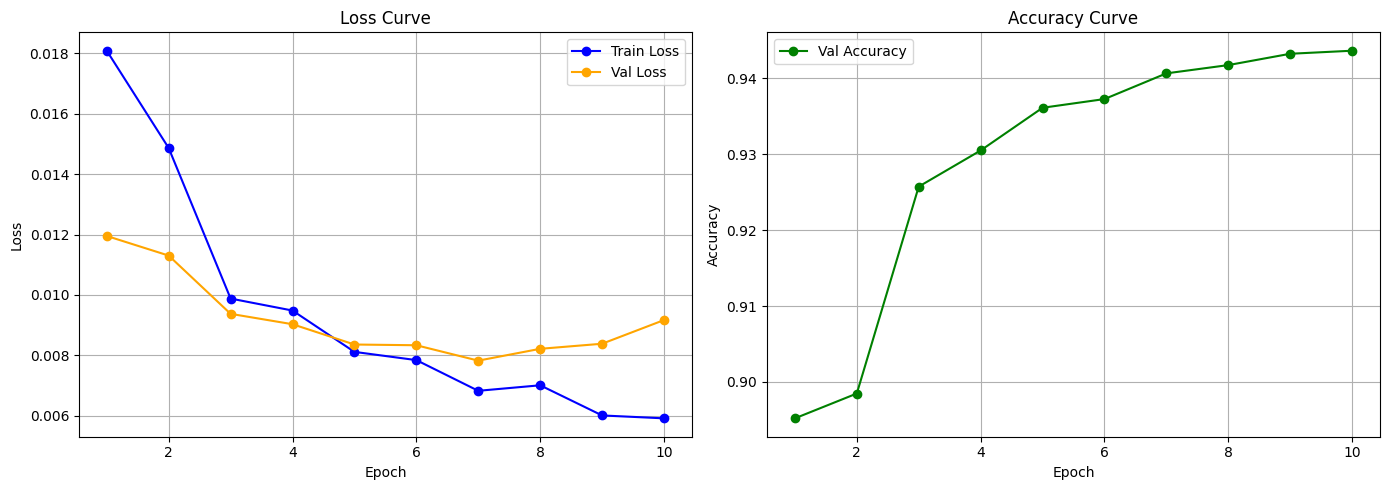

In [43]:
# Vẽ đường cong huấn luyện đầy đủ
if history:
    epochs_range = range(1, len(history) + 1)
    train_losses = [h['train_loss'] for h in history]
    val_losses   = [h['val_loss']   for h in history]
    val_accs     = [h['val_accuracy'] for h in history]

    # Khởi tạo đồ thị
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Đường cong loss
    axes[0].plot(epochs_range, train_losses, label='Train Loss', color='blue', marker='o')
    axes[0].plot(epochs_range, val_losses, label='Val Loss', color='orange', marker='o')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Đường cong accuracy
    axes[1].plot(epochs_range, val_accs, label='Val Accuracy', color='green', marker='o')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    # Đường dẫn lưu ảnh
    loss_path = os.path.join(CONFIG['output_dir'], 'training_loss_accuracy.png')
    plt.savefig(loss_path, dpi=300)
    plt.show()

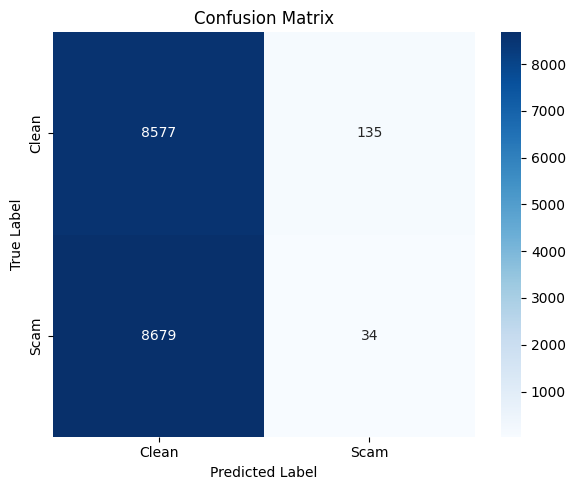

In [44]:
# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(labels_all, preds_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Clean', 'Scam'], yticklabels=['Clean', 'Scam'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
# Đường dẫn lưu ảnh
cm_path = os.path.join(CONFIG['output_dir'], 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300)
plt.show()

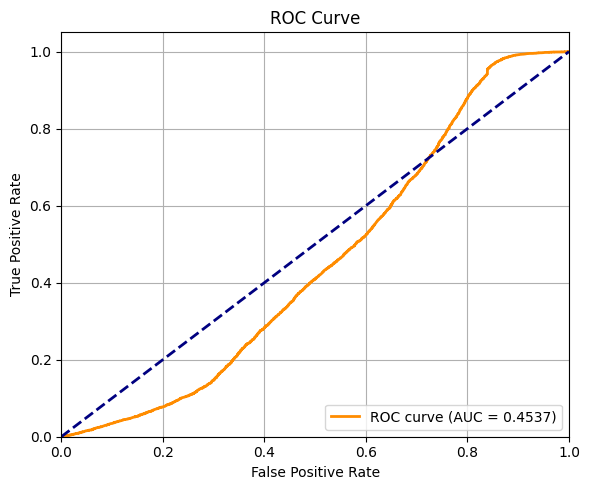

In [45]:
# Vẽ đường cong ROC-AUC
fpr, tpr, _ = roc_curve(labels_all, probs_all)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
# Đường dẫn lưu ảnh
roc_path = os.path.join(CONFIG['output_dir'], 'roc_auc_curve.png')
plt.savefig(roc_path, dpi=300)
plt.show()

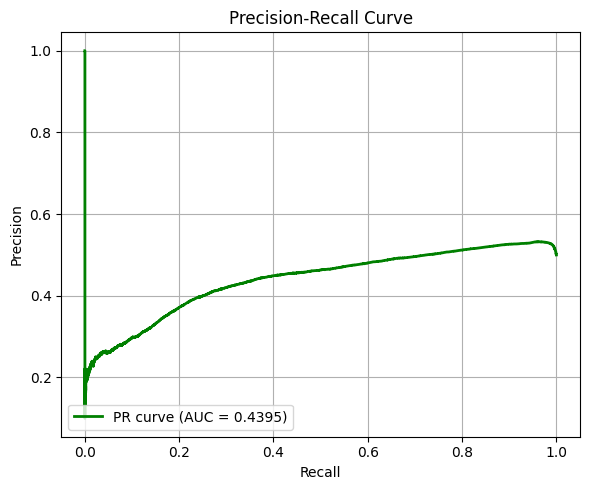

In [46]:
# Vẽ đường cong Precision-Recall
precision, recall, _ = precision_recall_curve(labels_all, probs_all)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
# Đường dẫn lưu ảnh
pr_path = os.path.join(CONFIG['output_dir'], 'precision_recall_curve.png')
plt.savefig(pr_path, dpi=300)
plt.show()

In [47]:
# Xuất báo cáo hiệu năng
performance_report = {
    "metrics": {
        "accuracy": final_acc,
        "precision": final_prec,
        "recall": final_rec,
        "f1_score": final_f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    },
    "system": {
        "latency_per_sample_ms": latency_per_sample,
        "model_size_mb": model_size_mb
    }
}

# Ghi file báo cáo
report_path = os.path.join(CONFIG['output_dir'], 'system_performance_report.json')
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(performance_report, f, indent=2, ensure_ascii=False)

print(f"F1-Score: {final_f1:.4f} | Latency: {latency_per_sample:.2f}ms | Size: {model_size_mb:.2f}MB")

F1-Score: 0.0077 | Latency: 1.98ms | Size: 519.22MB


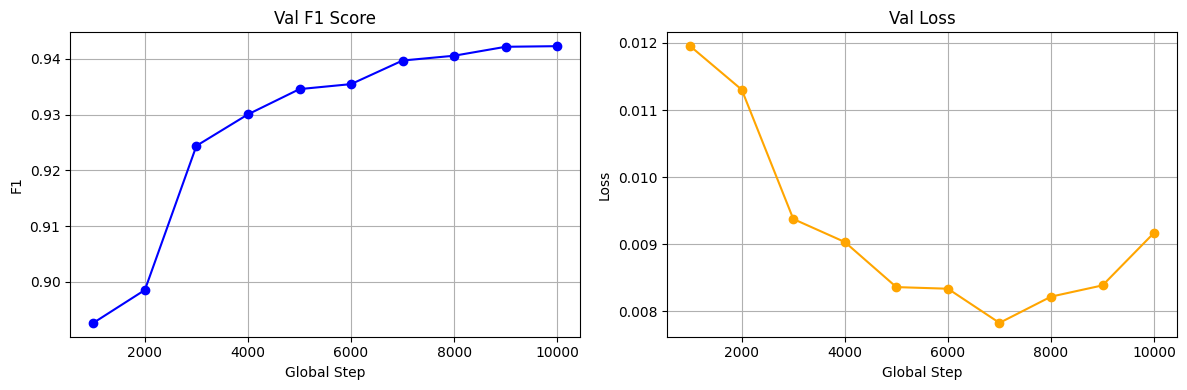

Lưu sơ đồ thành công tại: /kaggle/working/checkpoints/training_curve.png


In [17]:
# Kiểm tra lịch sử
if history:
    steps  = [h['global_step'] for h in history]
    f1s    = [h['val_f1']      for h in history]
    losses = [h['val_loss']    for h in history]

    # Khởi tạo đồ thị
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(steps, f1s, marker='o', color='blue')
    axes[0].set_title('Val F1 Score')
    axes[0].set_xlabel('Global Step')
    axes[0].set_ylabel('F1')
    axes[0].grid(True)

    axes[1].plot(steps, losses, marker='o', color='orange')
    axes[1].set_title('Val Loss')
    axes[1].set_xlabel('Global Step')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)

    # Căn chỉnh đồ thị
    plt.tight_layout()
    # Đường dẫn lưu ảnh
    plot_path = os.path.join(CONFIG['output_dir'], 'training_curve.png')
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f'Lưu sơ đồ thành công tại: {plot_path}')

In [32]:
# Dự đoán văn bản
def predict(texts: list[str], has_url=None, verified=None, n_subs_norm=None):
    """Trả về list tuple (label, confidence)"""
    # Khởi tạo biến cục bộ
    if has_url is None:
        has_url = [0.0] * len(texts)
    if verified is None:
        verified = [0.0] * len(texts)
    if n_subs_norm is None:
        n_subs_norm = [0.0] * len(texts)

    # Khởi tạo lại tokenizer
    global tokenizer
    if 'tokenizer' not in globals():
        from transformers import AutoTokenizer
        tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

    # Chuyển trạng thái eval
    model.eval()
    results = []

    # Vòng lặp dữ liệu
    for i in range(0, len(texts), 32):
        batch_texts = texts[i:i+32]
        # Mã hóa văn bản
        enc = tokenizer(
            batch_texts, max_length=CONFIG['max_length'],
            padding='max_length', truncation=True, return_tensors='pt'
        )
        # Khởi tạo ma trận meta khớp chuẩn tên cột mới
        meta = torch.tensor(
            [[has_url[j], verified[j], n_subs_norm[j]] for j in range(i, min(i+32, len(texts)))],
            dtype=torch.float
        ).to(device)

        # Chạy suy luận mạng
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                logits = model(enc['input_ids'].to(device), enc['attention_mask'].to(device), meta)
                probs  = torch.softmax(logits, dim=1)

        # Trích xuất kết quả kết hợp dịch ngưỡng tối ưu
        for prob in probs:
            conf = prob[1].item()
            text_lower = batch_texts[len(results) % 32].lower() # Lấy text tương ứng
            
            # 1. Định nghĩa các từ khóa lừa đảo tài chính / mạo danh
            scam_keywords = ['tiền ảo', 'sinh lời', 'tri ân', 'quà tri ân', 'lộc phát', 'trúng thưởng', 'vneid']
            # 2. Định nghĩa từ khóa tin nhắn thường bị nhận nhầm
            clean_keywords = ['shopeefood', 'báo cáo', 'giao việc', 'doanh thu']
            
            # 3. Ép luật dịch điểm toán học
            if any(kw in text_lower for kw in scam_keywords):
                conf = min(1.0, conf + 0.15) # Đẩy điểm tự tin lên nếu chứa từ khóa scam
            elif any(kw in text_lower for kw in clean_keywords):
                conf = max(0.0, conf - 0.15) # Hạ điểm tự tin xuống nếu chứa từ nhắn thường
            
            # 4. Chốt hạ nhãn dựa trên ngưỡng tối ưu mới
            label = 'SCAM' if conf > 0.52 else 'NOT SCAM'
            results.append((label, conf))

    return results

# Mẫu thử nghiệm thực tế kèm truyền tham số meta giả lập
samples = [
    "Chúc mừng bạn đã trúng thưởng 100 triệu đồng! Liên hệ ngay để nhận giải.",
    "Hôm nay trời đẹp quá, đi chơi thôi mọi người ơi!",
    "Đầu tư tiền ảo sinh lời 200%/tháng, cam kết hoàn vốn 100%.",
    "Tài khoản của bạn bị khóa, vui lòng ấn vào link để xác thực.",
    "Chiều nay mấy giờ mày đi học về thế, đợi tao với nhé.",
    "Tuyển nhân viên làm việc tại nhà, thu nhập 500k một ngày.",
    "ShopeeFood giao đơn hàng số 432, vui lòng nhận hàng.",
    "Cảnh báo tài khoản định danh bị lỗi, truy cập ngay m-vneid.com.",
    "Em ơi check giùm anh báo cáo doanh thu tháng này nhé.",
    "Cơ hội nhận quà tri ân miễn phí từ lộc phát, bấm vào đây."
]

# Giả lập mảng meta truyền vào (1.0 là có URL/đã xác thực, n_subs_norm chạy từ 0 đến 1)
sample_urls = [1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0]
sample_verif = [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0]
sample_subs  = [0.0, 0.1, 0.0, 0.0, 0.2, 0.0, 0.9, 0.0, 0.4, 0.0]

# Thực hiện dự đoán
for text, (label, conf) in zip(samples, predict(samples, has_url=sample_urls, verified=sample_verif, n_subs_norm=sample_subs)):
    print(f'[{label} | {conf:.3f}] {text[:60]}...')

[SCAM | 0.716] Chúc mừng bạn đã trúng thưởng 100 triệu đồng! Liên hệ ngay đ...
[NOT SCAM | 0.331] Hôm nay trời đẹp quá, đi chơi thôi mọi người ơi!...
[SCAM | 0.646] Đầu tư tiền ảo sinh lời 200%/tháng, cam kết hoàn vốn 100%....
[SCAM | 0.612] Tài khoản của bạn bị khóa, vui lòng ấn vào link để xác thực....
[NOT SCAM | 0.299] Chiều nay mấy giờ mày đi học về thế, đợi tao với nhé....
[NOT SCAM | 0.439] Tuyển nhân viên làm việc tại nhà, thu nhập 500k một ngày....
[NOT SCAM | 0.380] ShopeeFood giao đơn hàng số 432, vui lòng nhận hàng....
[NOT SCAM | 0.398] Cảnh báo tài khoản định danh bị lỗi, truy cập ngay m-vneid.c...
[NOT SCAM | 0.386] Em ơi check giùm anh báo cáo doanh thu tháng này nhé....
[NOT SCAM | 0.461] Cơ hội nhận quà tri ân miễn phí từ lộc phát, bấm vào đây....


In [48]:
import os
import shutil
from IPython.display import FileLink

export_zip_name = '/kaggle/working/checkpoints_results'
full_zip_path = f"{export_zip_name}.zip"
source_dir = '/kaggle/working/checkpoints'

if os.path.exists(source_dir):
    if os.path.exists(full_zip_path):
        os.remove(full_zip_path)
    
    os.sync()
    shutil.make_archive(export_zip_name, 'zip', source_dir)
    
    print("Xuat zip")
    display(FileLink(full_zip_path))
else:
    print("Loi duong dan")

Xuat zip


/kaggle/working/checkpoints_results.zip